In [ ]:
# here i will try to code cause in this way might get familiar wiht the python syntax


In [1]:
# importing imp lib

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as  plt
import matplotlib.gridspec as gridspec
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

So basically I got this dataset from Kaggle credit cards csv
the description for this dataset is This is about transactions of european people and this had features but because of confidentiality we dont have features but they ve given us the pca transformation 28 components so we can use them as our features we also have some col such as time and amount , te class label is fraud 1 or normal 0 all are numerical data and 
time is time between first and that transaction and amount is the amount of that trnasaccion lets see what we cna do here first we need to start with eda of this data 
also there no info about specific info we are looking at this problem from transaction side only just identify which specific transaciton is fraud then get trnasaciton id then form normalised table we can automatically block the user credit card

What people normally do in eda start with describe info check for structure of dat base how many values value count is null chcek then outlier check , check mean median mode etc sd lets start doing this by using descibe info and other pd functio


In [2]:
df=pd.read_csv("creditcard.csv")
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# this function provided with no of col name and tpye and non null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# this gives us count mean std min max percentile data 
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
from sklearn.impute import KNNImputer
# from sklearn.impute import IterativeImputer


# Check how many missing values per column
#print("NA counts per column:\n", df.isnull().sum())

# 1) Drop missing values
df_drop_rows = df.dropna()            # drop any row with >=1 NA
df_drop_cols = df.dropna(axis=1)      # drop any column with >=1 NA

# 2) Simple fills (column-wise)
df_fill_mean   = df.fillna(df.mean())     # replace NA with column mean (numeric cols)
df_fill_median = df.fillna(df.median())   # replace NA with column median
# mode: for mixed types (use first mode value per column)
modes = df.mode().iloc[0]
df_fill_mode   = df.fillna(modes)

# 3) Fill a single column (inplace example)
# df['Amount'].fillna(df['Amount'].median(), inplace=True)

# 4) Forward / backward fill
df_ffill = df.fillna(method='ffill')   # propagate last valid observation forward
df_bfill = df.fillna(method='bfill')   # propagate next valid observation backward

# 5) Interpolation (good for ordered/time data)
df_interp = df.interpolate(method='linear')   # linear interpolation

# 6) Replace with a constant
df_zero = df.fillna(0)

# 7) Model-based imputation
# KNN imputer (numeric columns only)
num_cols = df.select_dtypes(include=np.number).columns
knn_imp = KNNImputer(n_neighbors=5)
df_knn = df.copy()
df_knn[num_cols] = knn_imp.fit_transform(df[num_cols])

# Iterative imputer (MICE-like)
# from sklearn.experimental import enable_iterative_imputer  # noqa: F401
# it_imp = IterativeImputer(random_state=0, max_iter=10)
# df_iter = df.copy()
# df_iter[num_cols] = it_imp.fit_transform(df[num_cols])

# Notes:
# - Don't call inplace operations until you're sure (keep copies).
# - Choose mean vs median based on skew/outliers (median robust to outliers).
# - Forward/backward fills and interpolation suit time-series.
# - Use KNN/Iterative imputers when relationships between features matter.
# - Evaluate imputation impact downstream (e.g., with cross-validation).

In [7]:
from sklearn.ensemble import IsolationForest

# here lets identify outlier 
# but this was pca data so no point of checking outlier but just to get 
# used to syntaax of outlier removal doing thi
# Outlier detection & replacement examples (using the filled dataframe)
data = df_fill_median.copy()   # use existing filled dataframe
num_cols = data.select_dtypes(include=np.number).columns.drop('Class', errors='ignore')

# 1) IQR method (detect, drop, cap, replace with median)
Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outlier_mask = ((data[num_cols] < lower) | (data[num_cols] > upper)).any(axis=1)
print("IQR detected outlier rows:", iqr_outlier_mask.sum())

df_iqr_dropped = data.loc[~iqr_outlier_mask].copy()               # drop rows with any IQR outlier
df_iqr_capped  = data.copy()
df_iqr_capped[num_cols] = df_iqr_capped[num_cols].clip(lower=lower, upper=upper, axis=1)  # cap to bounds
df_iqr_median  = data.copy()
for c in num_cols:
    mask = (df_iqr_median[c] < lower[c]) | (df_iqr_median[c] > upper[c])
    df_iqr_median.loc[mask, c] = df_iqr_median[c].median()       # replace outliers with median

# 2) Z-score method (univariate, common threshold is 3)
means = data[num_cols].mean()
stds  = data[num_cols].std()
z_scores = (data[num_cols] - means) / stds
z_outlier_mask = (z_scores.abs() > 3).any(axis=1)
print("Z-score detected outlier rows (|z|>3):", z_outlier_mask.sum())

df_z_replaced = data.copy()
for c in num_cols:
    mask = (z_scores[c].abs() > 3)
    df_z_replaced.loc[mask, c] = data[c].median()                 # replace with median

# 3) Percentile capping / Winsorization (e.g., 1st/99th percentiles)
low_p = data[num_cols].quantile(0.01)
high_p = data[num_cols].quantile(0.99)
df_winsor = data.copy()
df_winsor[num_cols] = df_winsor[num_cols].clip(lower=low_p, upper=high_p, axis=1)
print("Winsorization applied using 1st/99th percentiles.")

# 4) Model-based multivariate detection: IsolationForest
iso = IsolationForest(contamination=0.01, random_state=42)
iso_preds = iso.fit_predict(data[num_cols])   # -1 = outlier, 1 = inlier
iso_mask = iso_preds == -1
print("IsolationForest detected outlier rows (~1% cont.):", iso_mask.sum())
df_iso_removed = data.loc[~iso_mask].copy()

# Quick summary of results
print("\nShapes:")
print(" original:", data.shape)
print(" iqr_dropped:", df_iqr_dropped.shape)
print(" iqr_capped:", df_iqr_capped.shape)
print(" iqr_median_replaced:", df_iqr_median.shape)
print(" z_replaced:", df_z_replaced.shape)
print(" winsorized:", df_winsor.shape)
print(" iso_removed:", df_iso_removed.shape)

# Example: inspect a few rows flagged by different methods
example_idx = data.index[iqr_outlier_mask | z_outlier_mask | iso_mask][:10]
print("\nExample flagged rows (first 10 indices):", list(example_idx))
data.loc[example_idx].head()


IQR detected outlier rows: 138473
Z-score detected outlier rows (|z|>3): 37816
Winsorization applied using 1st/99th percentiles.
IsolationForest detected outlier rows (~1% cont.): 2849

Shapes:
 original: (284807, 31)
 iqr_dropped: (146334, 31)
 iqr_capped: (284807, 31)
 iqr_median_replaced: (284807, 31)
 z_replaced: (284807, 31)
 winsorized: (284807, 31)
 iso_removed: (281958, 31)

Example flagged rows (first 10 indices): [2, 7, 8, 11, 14, 18, 20, 21, 23, 24]


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
11,10.0,0.384978,0.616109,-0.874300,-0.094019,2.924584,3.317027,0.470455,0.538247,-0.558895,...,0.049924,0.238422,0.009130,0.996710,-0.767315,-0.492208,0.042472,-0.054337,9.99,0
14,12.0,-2.791855,-0.327771,1.641750,1.767473,-0.136588,0.807596,-0.422911,-1.907107,0.755713,...,1.151663,0.222182,1.020586,0.028317,-0.232746,-0.235557,-0.164778,-0.030154,58.80,0


In [8]:
# now lets calculate % fraud and non fraud accounts

fraud=int(df.Class.value_counts().iloc[1])
not_fraud=int(df.Class.value_counts().iloc[0])
fraud_pc=round((fraud*100/(not_fraud+fraud)),2)
print(f"percentage fraud is {fraud_pc}% ")
print(f"percentage not fraud is {1-fraud_pc}%")


percentage fraud is 0.17% 
percentage not fraud is 0.83%


In [9]:
# now lets try doing univarete and bivariate anlysis
# uni when only dep variable is use 
# main goal summarise 
# i think data m khud m kya variation h mean median mode std etc 
# if we take 2 features then we trying to find relation thence 
# its bivaritae



Text(0.5, 1.0, '0:Not Fraud and 1:Fraud')

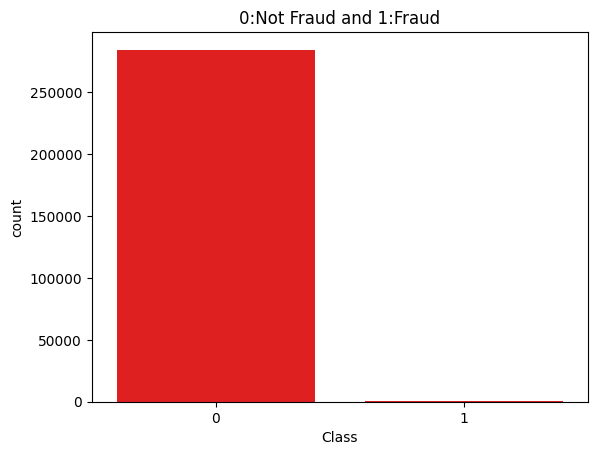

In [10]:
# we already know imbalance in class lets try to plot it self
sns.countplot(x="Class",data=df,color="red")
plt.title("0:Not Fraud and 1:Fraud")

In [11]:
amount_val=df['Amount'].values
max(amount_val),min(amount_val)

(np.float64(25691.16), np.float64(0.0))

Text(0.5, 1.0, 'Distribution of Amount')

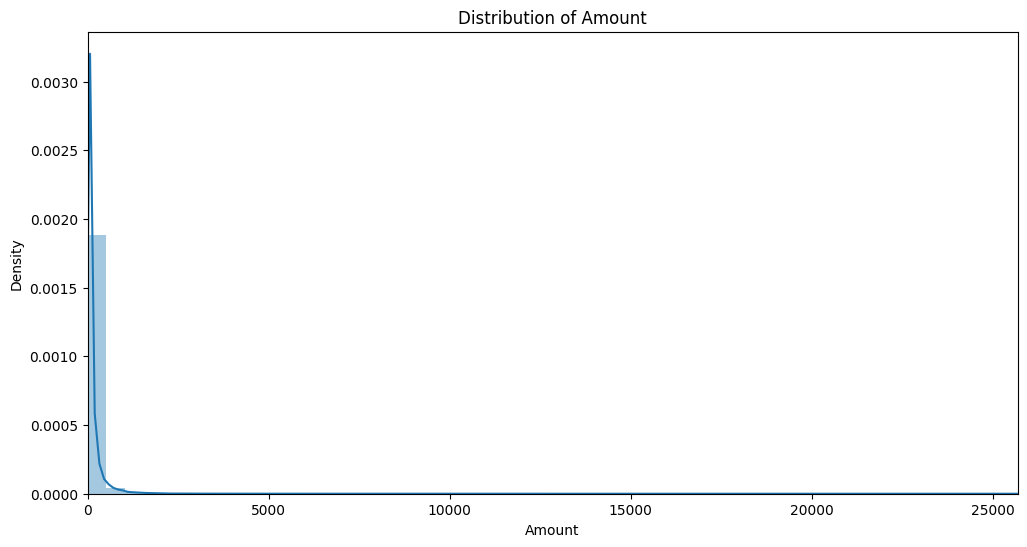

In [12]:
# now lets see distribution of amount 
amount_val=df['Amount'].values
plt.figure(figsize=(12,6))
#sns.histplot(df['Amount'])
sns.distplot(df["Amount"])
plt.xlim(min(amount_val),max(amount_val))
plt.title("Distribution of Amount")

Text(0.5, 1.0, 'Distribution of transaciton_data')

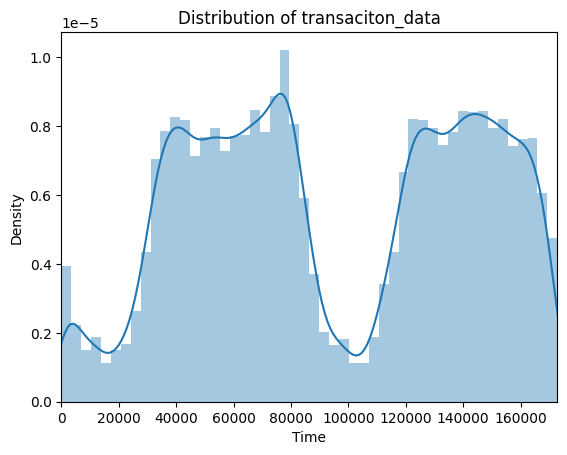

In [13]:
# lets see times distribution
time_val=df['Time'].values 
sns.distplot(df["Time"])
plt.xlim(min(time_val),max(time_val))
plt.title("Distribution of transaciton_data")

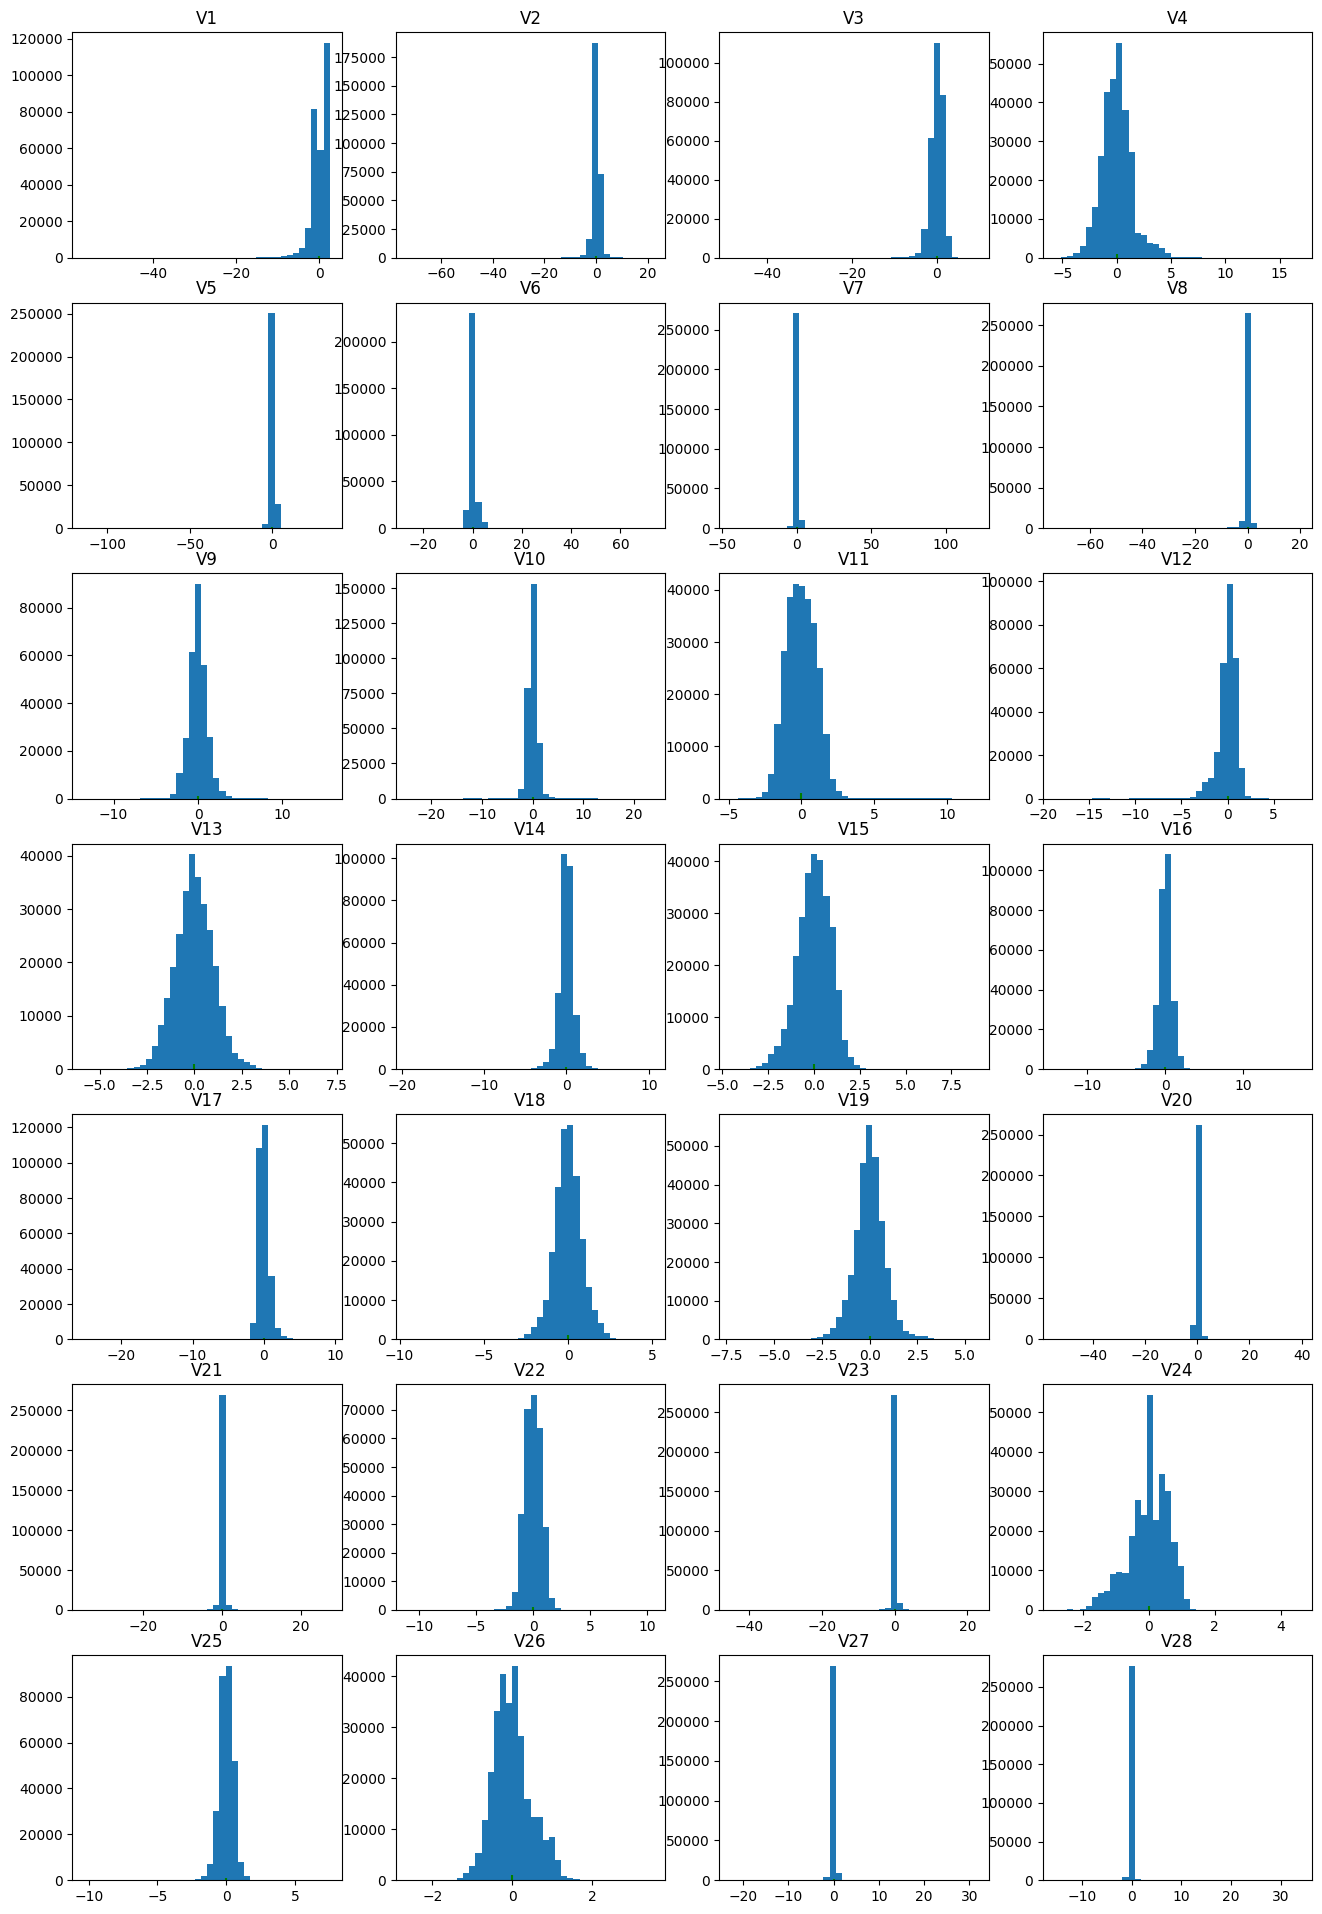

In [14]:
# now we had 17 pca axs need to plot them how 

fig,ax=plt.subplots(nrows=7,ncols=4,figsize=(16,24))

for i in range(1,29):
    
    m=(i-1)//4
    n=(i-1)%4
    col='V'+str(i)
    ax[m,n].hist(df[col],bins=40)
    ax[m,n].set_title(col)
    ax[m,n].vlines(x=df[col].mean(),ymin=0,ymax=10**3,linestyle='dashed',colors="g")
    ax[m,n].set_yscale=('log')

Text(0.5, 1.0, 'Amount vs Class')

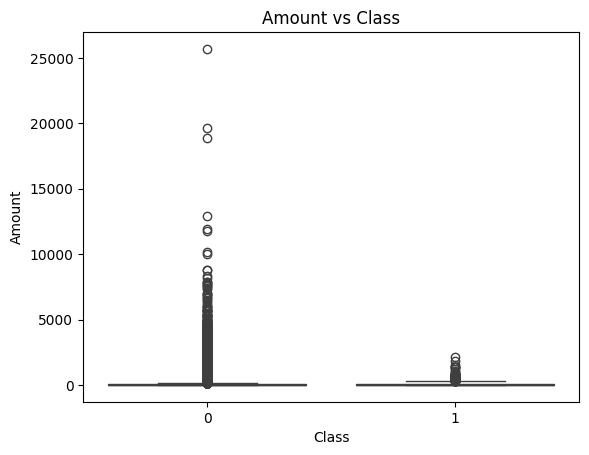

In [15]:
# bivariate analysis
# class vs amount
sns.boxplot(x="Class",y="Amount",data=df)
plt.title("Amount vs Class")

In [16]:
df=df[df["Amount"]<10000]
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,...,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000,284799.000000
mean,94813.586235,0.000716,0.001123,0.000542,-0.000326,0.000800,-0.000436,-0.000897,0.000198,0.000045,...,-0.000100,0.000140,0.000326,-0.000027,0.000103,0.000019,-0.000073,0.000008,87.927043,0.001728
std,47488.019368,1.953489,1.635632,1.511555,1.414375,1.359939,1.324170,1.210706,1.193066,1.098578,...,0.732325,0.724703,0.618721,0.605586,0.520394,0.482084,0.399034,0.328549,235.414278,0.041528
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-8.887017,-44.807735,-2.836627,-10.295397,-2.068561,-22.565679,-11.710896,0.000000,0.000000
25%,54202.500000,-0.920290,-0.598457,-0.890240,-0.848660,-0.691546,-0.768299,-0.554089,-0.208605,-0.643083,...,-0.228395,-0.542320,-0.161841,-0.354593,-0.317128,-0.326979,-0.070835,-0.052960,5.590000,0.000000
50%,84691.000000,0.018158,0.065524,0.179859,-0.019921,-0.054322,-0.274227,0.040079,0.022363,-0.051416,...,-0.029452,0.006795,-0.011191,0.040964,0.016607,-0.052124,0.001343,0.011243,22.000000,0.000000
75%,139320.000000,1.315648,0.803743,1.027212,0.743302,0.611927,0.398463,0.570385,0.327356,0.597164,...,0.186367,0.528554,0.147642,0.439524,0.350716,0.240952,0.091045,0.078277,77.150000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.491217,34.801666,22.529298,36.877368,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.022866,7.519589,3.517346,12.152401,33.847808,8790.260000,1.000000


<Axes: xlabel='Class', ylabel='Amount'>

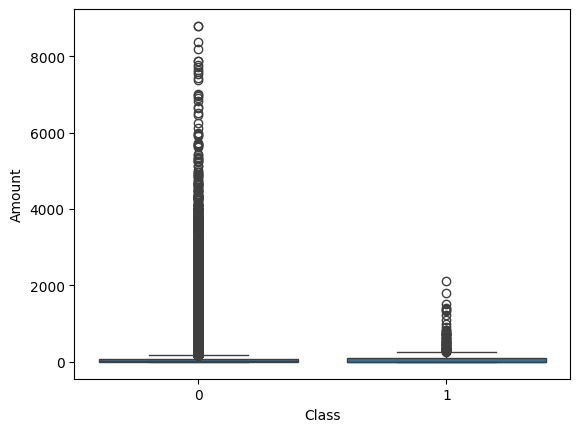

In [17]:
sns.boxplot(x="Class",y="Amount",data=df)

In [18]:
# lets see about time minute and hourse
timedelta=pd.to_timedelta(df.Time,unit='s')

df["time_minute"]=(timedelta.dt.components.minutes).astype(int) 
df["time_hour"]=(timedelta.dt.components.hours).astype(int) 

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,time_minute,time_hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0,0


Text(0.5, 1.0, 'Amounts by minutes fo Fraud and Normal Transactions')

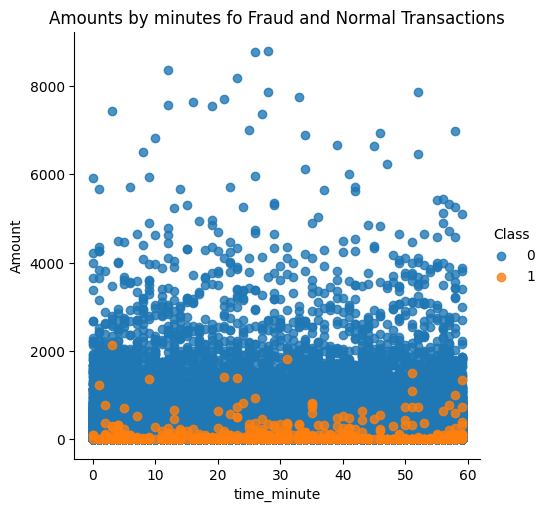

In [19]:
ax=sns.lmplot(y="Amount",x="time_minute",fit_reg=False,data=df,hue="Class")
plt.title("Amounts by minutes fo Fraud and Normal Transactions")


Text(0.5, 1.0, 'Amounts by minutes fo Fraud and Normal Transactions')

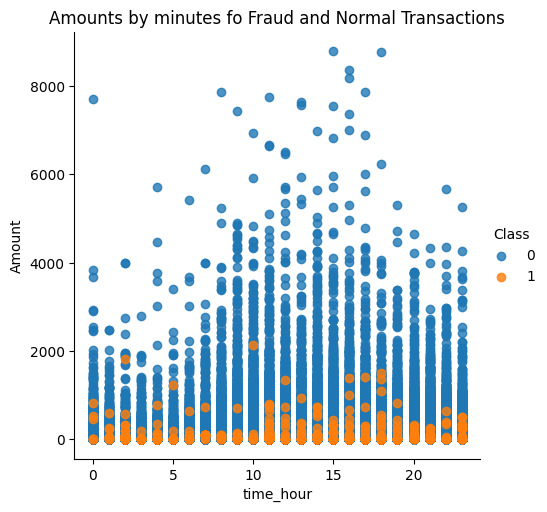

In [20]:
ax=sns.lmplot(y="Amount",x="time_hour",fit_reg=False,data=df,hue="Class")
plt.title("Amounts by minutes fo Fraud and Normal Transactions")


In [21]:
# now enough with this eda
# lets do data precprocessing and try to buuild idff model and then do 
# evaluation and build matrix

from sklearn.preprocessing import RobustScaler
rob_scaler=RobustScaler()
df["scaled_amount"]=rob_scaler.fit_transform(df["Amount"].values.reshape(-1,1))
df.drop(["Time","Amount"],axis=1,inplace=True)


In [22]:
scaled_amount=df.scaled_amount
df.drop(["scaled_amount"],axis=1,inplace=True)
df.insert(0,'scaled_amount',scaled_amount)
df.head()

,scaled_amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Class,time_minute,time_hour
0,1.783399,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0,0
1,-0.269843,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0,0
2,4.984069,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0,0
3,1.418390,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0,0
4,0.670626,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0,0


In [23]:
from sklearn.model_selection import StratifiedKFold

X = df.drop('Class',axis=1)
y = df['Class']

sss = StratifiedKFold(n_splits=5,random_state=None,shuffle=False)

for train_index, test_index in sss.split(X,y):
  print("Train:", train_index, "Test:", test_index)
  original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
  original_ytrain, original_ytest = y.iloc[train_index],y.iloc[test_index]

#converting it into an array
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

#check if both train and test distributions are similarly distributed
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest,return_counts=True)

print("Label dstributions: \n")
print(train_counts_label/len(original_ytrain))
print(test_counts_label/len(original_ytest))

Train: [ 30442  30473  30496 ... 284796 284797 284798] Test: [    0     1     2 ... 57016 57017 57018]
Train: [     0      1      2 ... 284796 284797 284798] Test: [ 30442  30473  30496 ... 113962 113963 113964]
Train: [     0      1      2 ... 284796 284797 284798] Test: [ 80757  81183  81606 ... 170942 170943 170944]
Train: [     0      1      2 ... 284796 284797 284798] Test: [150644 150651 150657 ... 227860 227861 227862]
Train: [     0      1      2 ... 227860 227861 227862] Test: [212511 212639 213087 ... 284796 284797 284798]
Label dstributions: 

[0.99827072 0.00172928]
[0.99827946 0.00172054]


In [24]:
# now we have to fix class imbalance for
# we can do undersampling oversampling smote
# best in smote

# try undersampling
# before doing that lets shuffle data 
df=df.sample(frac=1)

fraud_df=df.loc[df["Class"]==1]
non_fraud_df=df.loc[df["Class"]==0][:492]

normal_dist_df=pd.concat([fraud_df,non_fraud_df])

new_df=normal_dist_df.sample(frac=1,random_state=42)
#new_df.head()

# we only took 492 sample of non fraud and all of fraud hence did udnesrampling
# also took care we dont take bias hence first did shuffle
new_df["Class"].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

Text(0.5, 1.0, 'SubSample Correlation Matrix \n (use for reference)')

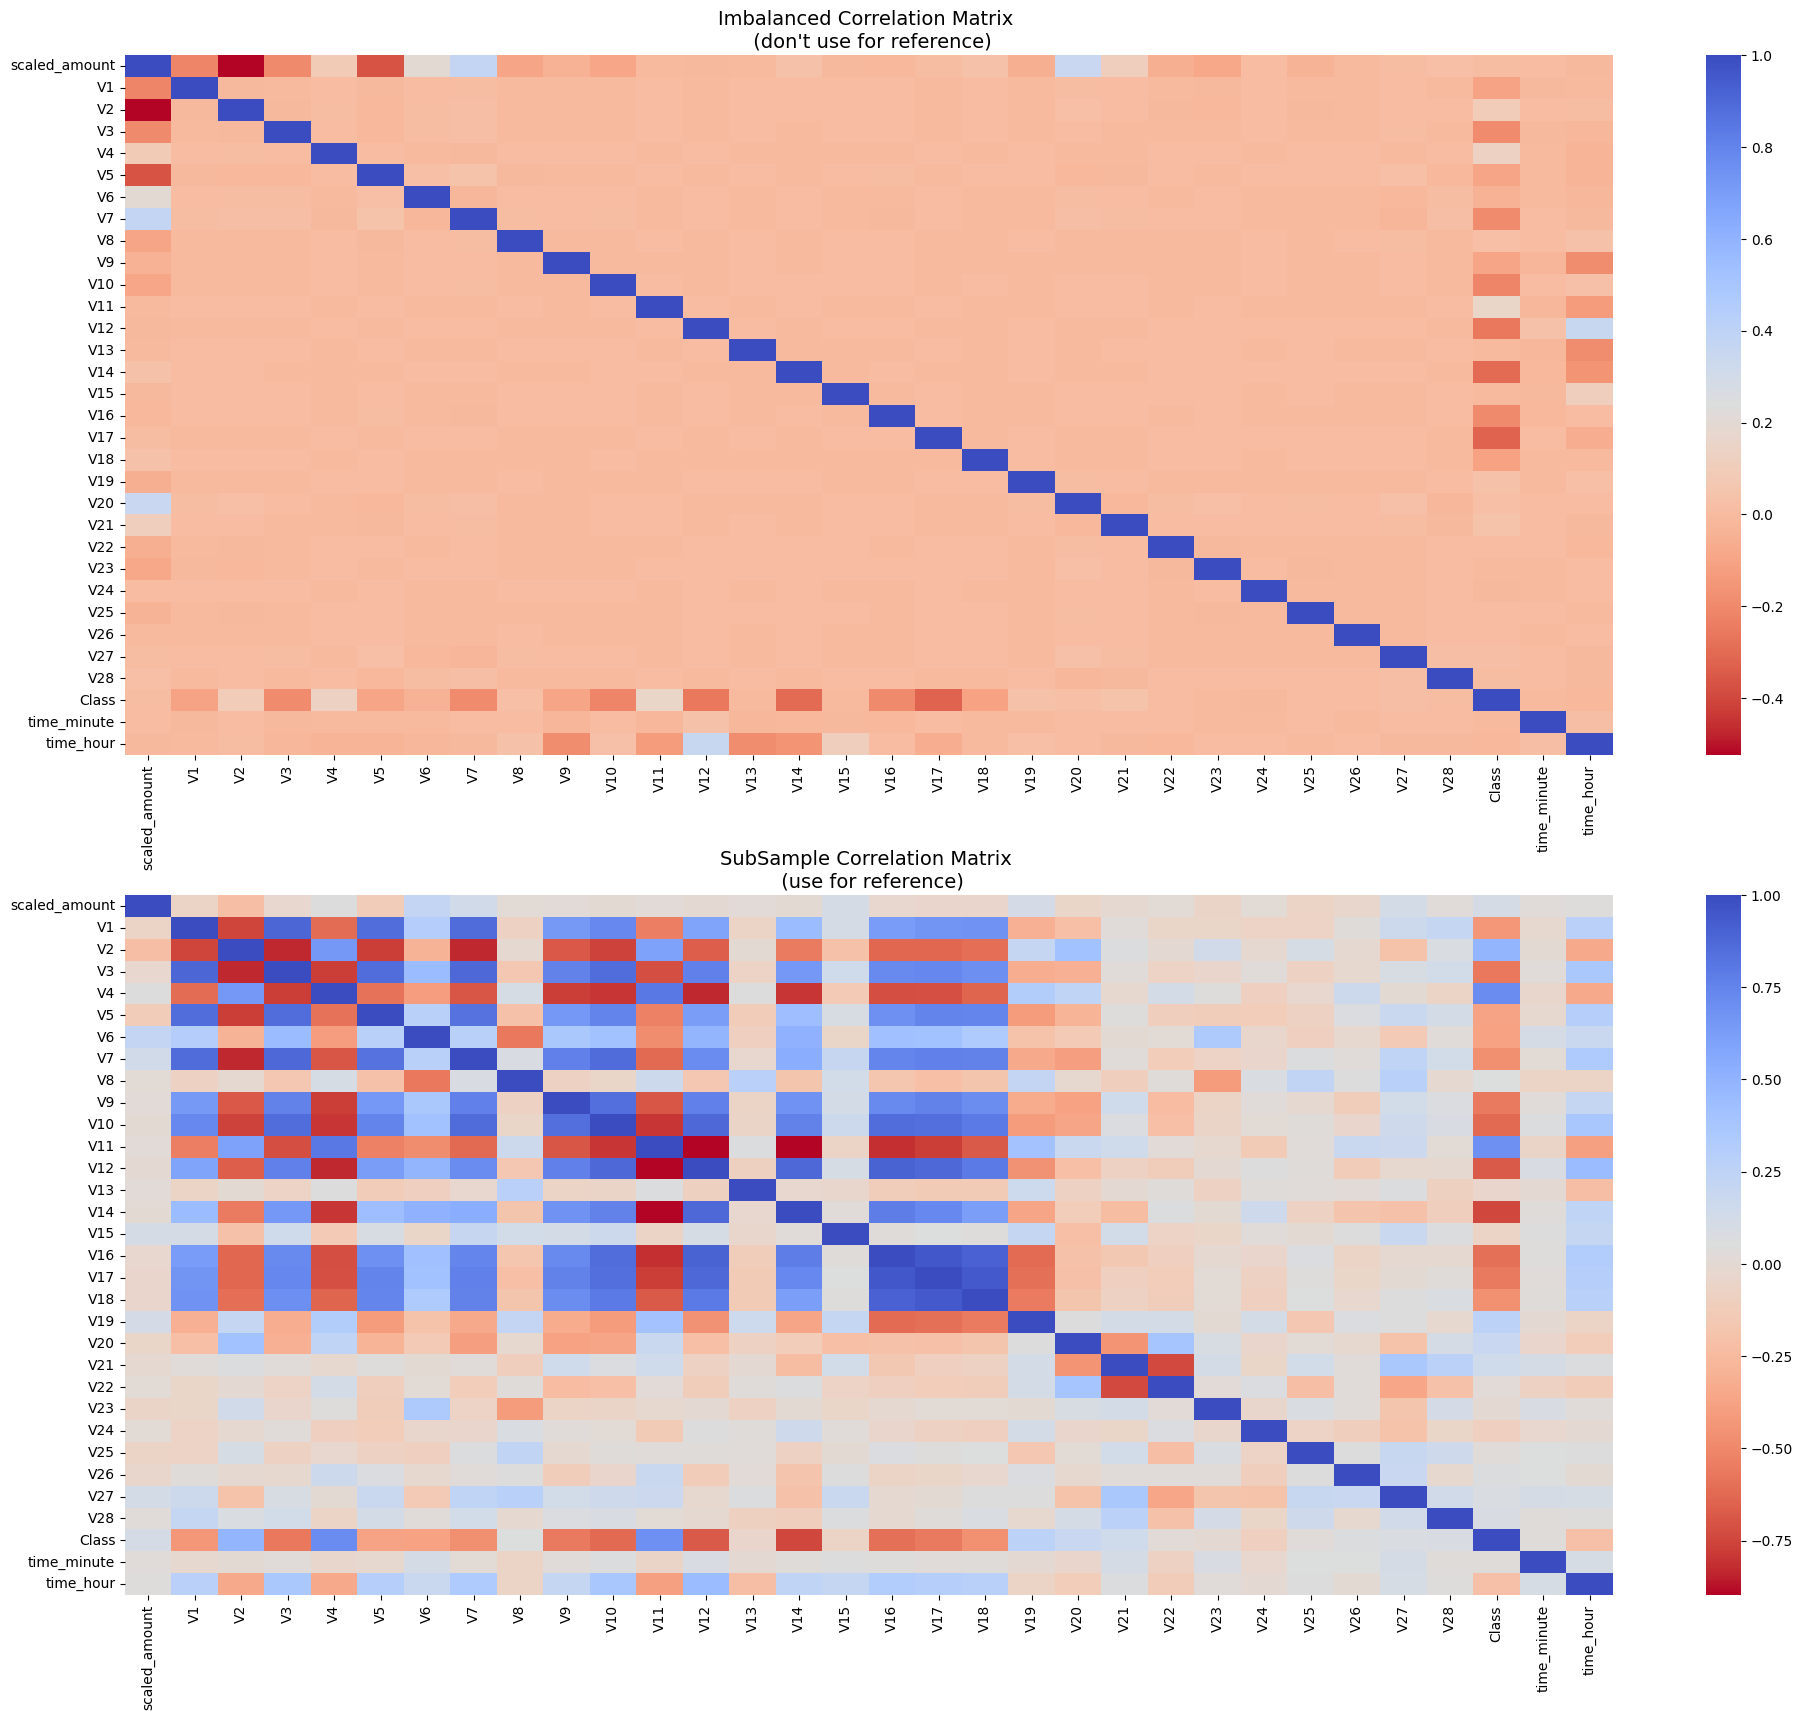

In [25]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# comparing correlation between dataset
# Entire DataFrame
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize=14)

# new_df
sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title('SubSample Correlation Matrix \n (use for reference)', fontsize=14)

In [26]:
corr=new_df.corr()
corr["Class"]
corr["Class"][corr["Class"]<-0.6]

V10   -0.627066
V12   -0.681107
V14   -0.745742
Name: Class, dtype: float64

In [27]:
corr=new_df.corr()
corr["Class"]
corr["Class"][corr["Class"]>0.5]

V4       0.716827
V11      0.688974
Class    1.000000
Name: Class, dtype: float64

<Axes: xlabel='Class', ylabel='V11'>

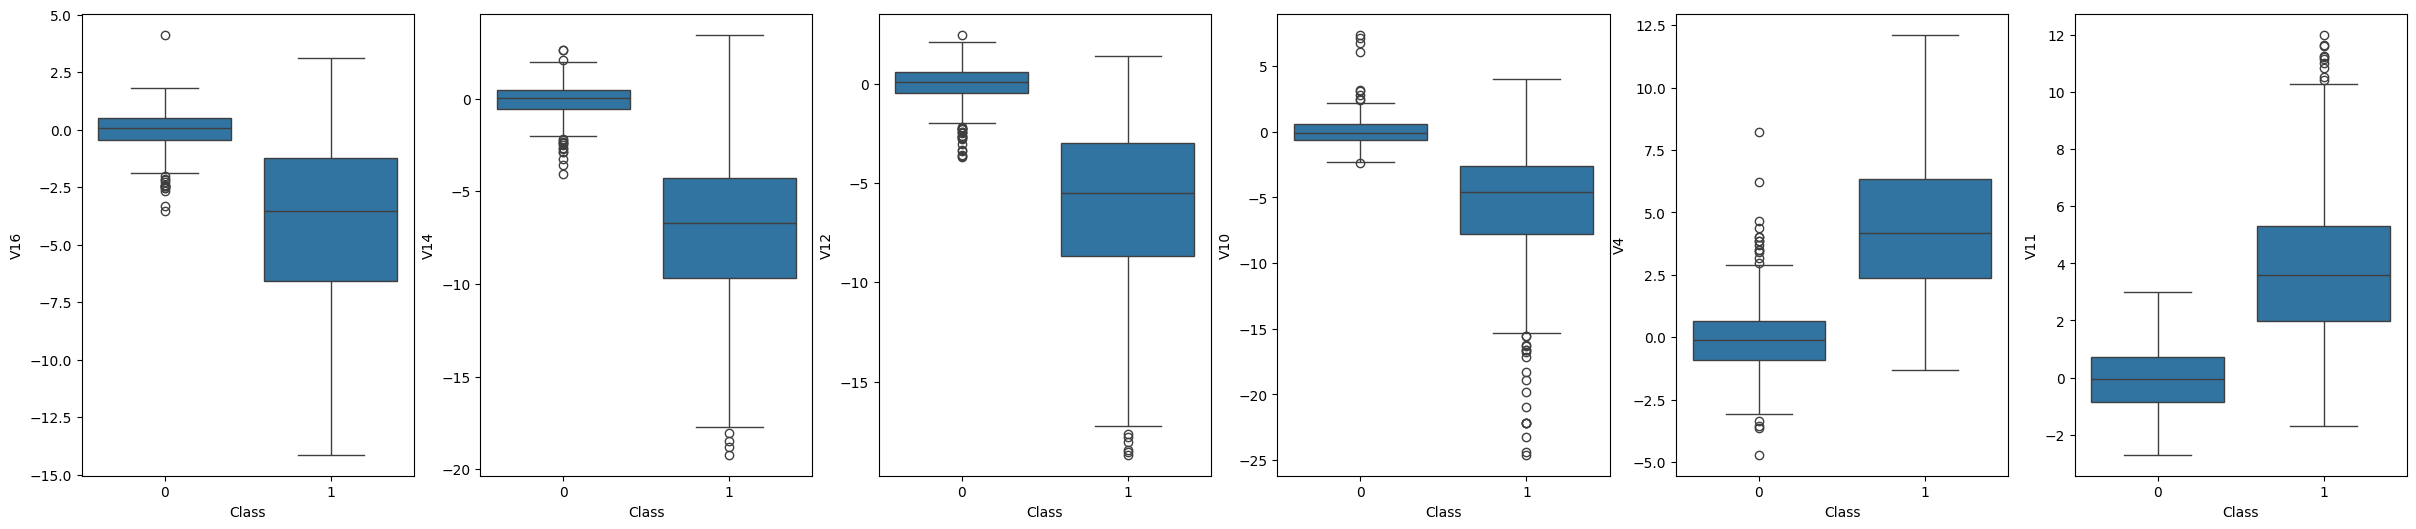

In [28]:
f,axes=plt.subplots(ncols=6,figsize=(30,6))
sns.boxplot(x="Class",y='V16',data=new_df,ax=axes[0])
sns.boxplot(x="Class",y='V14',data=new_df,ax=axes[1])
sns.boxplot(x="Class",y='V12',data=new_df,ax=axes[2])
sns.boxplot(x="Class",y='V10',data=new_df,ax=axes[3])
sns.boxplot(x="Class",y='V4',data=new_df,ax=axes[4])
sns.boxplot(x="Class",y='V11',data=new_df,ax=axes[5])



<Axes: ylabel='Density'>

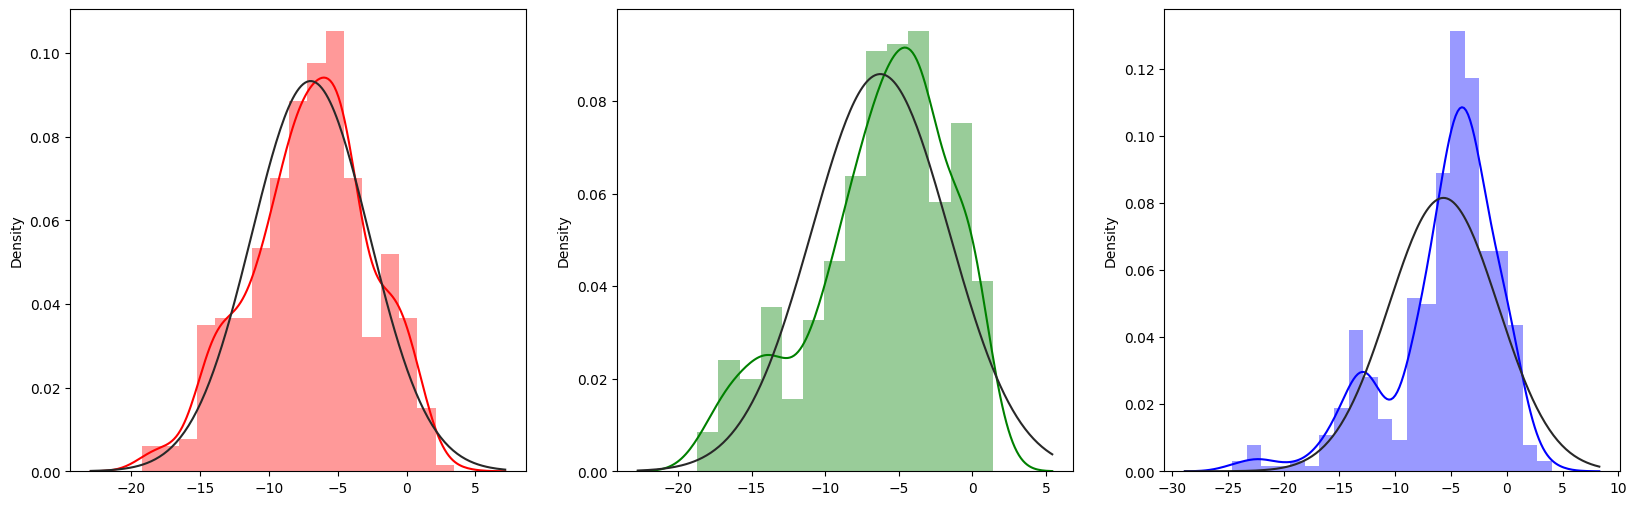

In [29]:
from scipy.stats import norm 
f,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(20,6))

v14_fraud_dist=new_df["V14"][df["Class"]==1].values
sns.distplot(v14_fraud_dist,ax=ax1,fit=norm,color="red")
v12_fraud_dist=new_df["V12"][df["Class"]==1].values
sns.distplot(v12_fraud_dist,ax=ax2,fit=norm,color="green")
v10_fraud_dist=new_df["V10"][df["Class"]==1].values
sns.distplot(v10_fraud_dist,ax=ax3,fit=norm,color="blue")


In [30]:
#Complete Line 2-16
v14_fraud = new_df['V14'].loc[new_df['Class'] == 1].values
q25, q75 =np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
print('Quartile 25: {} | Quartile 75: {}'.format(q25, q75))
v14_iqr =q75 - q25
print('iqr: {}'.format(v14_iqr))
v14_cut_off =v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off
print('Cut Off: {}'.format(v14_cut_off))
print('V14 Lower: {}'.format(v14_lower))
print('V14 Upper: {}'.format(v14_upper))

outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print('Feature V14 Outliers for Fraud Cases: {}'.format(len(outliers)))
print('V14 outliers:{}'.format(outliers))
new_df = new_df.drop(new_df[(new_df['V14'] > v14_upper) | (new_df['V14'] < v14_lower)].index)
print('----' * 44)

###################################################################################################################

v12_fraud = new_df['V12'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25
v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off
print('V12 Lower: {}'.format(v12_lower))
print('V12 Upper: {}'.format(v12_upper))
outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print('V12 outliers: {}'.format(outliers))
print('Feature V12 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V12'] > v12_upper) | (new_df['V12'] < v12_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))
print('----' * 44)

##################################################################################################################

v10_fraud = new_df['V10'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25
v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('V10 Lower: {}'.format(v10_lower))
print('V10 Upper: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('V10 outliers: {}'.format(outliers))
print('Feature V10 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V10'] > v10_upper) | (new_df['V10'] < v10_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))

Quartile 25: -9.692722964972386 | Quartile 75: -4.282820849486865
iqr: 5.409902115485521
Cut Off: 8.114853173228282
V14 Lower: -17.807576138200666
V14 Upper: 3.8320323237414167
Feature V14 Outliers for Fraud Cases: 4
V14 outliers:[np.float64(-18.4937733551053), np.float64(-19.2143254902614), np.float64(-18.0499976898594), np.float64(-18.8220867423816)]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V12 Lower: -17.3430371579634
V12 Upper: 5.776973384895937
V12 outliers: [np.float64(-18.6837146333443), np.float64(-18.0475965708216), np.float64(-18.5536970096458), np.float64(-18.4311310279993)]
Feature V12 Outliers for Fraud Cases: 4
Number of Instances after outliers removal: 976
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V10 Lo

<Axes: xlabel='Class', ylabel='V11'>

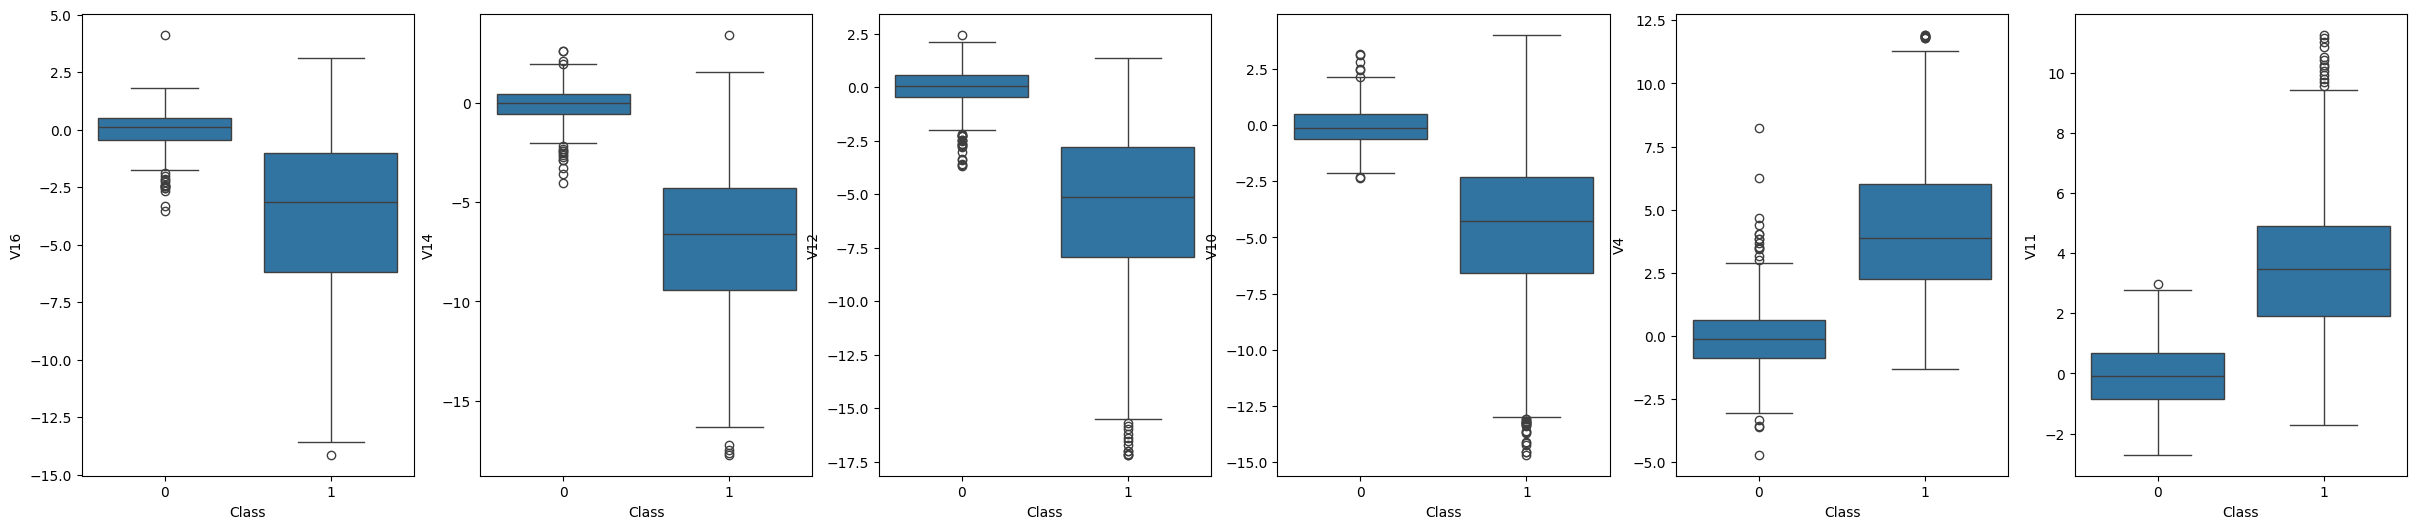

In [31]:
f,axes=plt.subplots(ncols=6,figsize=(30,6))
sns.boxplot(x="Class",y='V16',data=new_df,ax=axes[0])
sns.boxplot(x="Class",y='V14',data=new_df,ax=axes[1])
sns.boxplot(x="Class",y='V12',data=new_df,ax=axes[2])
sns.boxplot(x="Class",y='V10',data=new_df,ax=axes[3])
sns.boxplot(x="Class",y='V4',data=new_df,ax=axes[4])
sns.boxplot(x="Class",y='V11',data=new_df,ax=axes[5])



In [34]:
# lets do dimensionality reduction because there is correlated feautres


from sklearn.manifold import TSNE  
from sklearn.decomposition import PCA,TruncatedSVD
import matplotlib.patches as mpatches 
import time

x=new_df.drop("Class",axis=1)
y=new_df["Class"]

t0=time.time()
X_reduced_tsne=TSNE(n_components=2,random_state=42).fit_transform(x.values)
t1=time.time()
print(f"T-SNE Took {t1-t0}s")

#pca implement
t0=time.time()
X_reduced_pca=PCA(n_components=2,random_state=42).fit_transform(x.values)
t1=time.time()
print(f"PCA took {t1-t0}s")

# truncated SVD
t0=time.time()
X_reduced_svd=TruncatedSVD(n_components=2,random_state=42).fit_transform(x.values)
t1=time.time()
print(f"svd took {t1-t0}s")


T-SNE Took 2.0491323471069336s
PCA took 0.001127481460571289s
svd took 0.0023920536041259766s


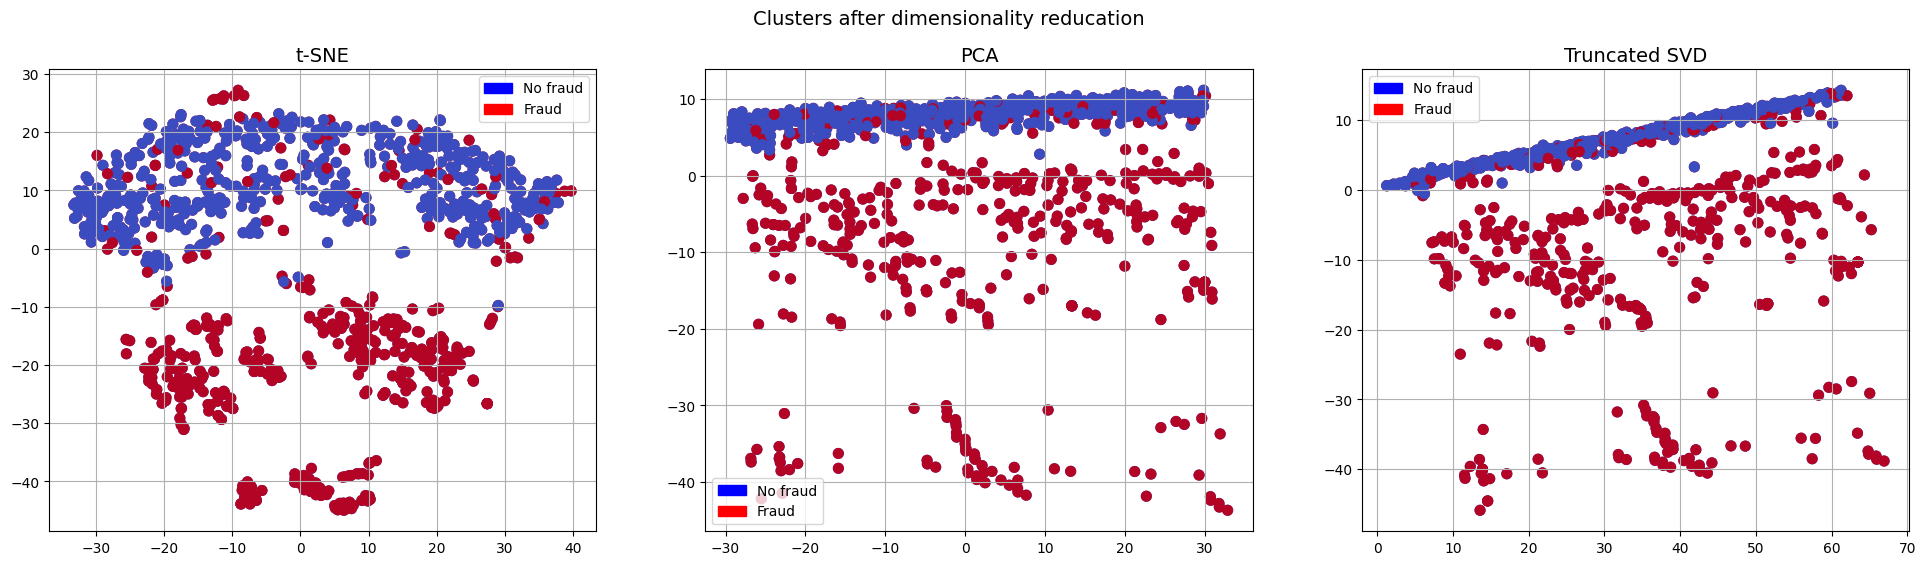

In [35]:
f, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(24,6))
f.suptitle('Clusters after dimensionality reducation',fontsize=14)

blue_patch = mpatches.Patch(color='blue',label = 'No fraud')
red_patch = mpatches.Patch(color='red',label='Fraud')

# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)
ax1.grid(True)
ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)
ax2.grid(True)
ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)
ax3.grid(True)
ax3.legend(handles=[blue_patch, red_patch])

In [39]:
# lets try putting models

x=new_df.drop('Class',axis=1)
y=new_df["Class"]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)


In [ ]:
# x_train=x_train.values 
# x_test=x_test.values
# y_train=y_train.values 
# y_test=y_test.values 
# this is not necessary or compulsory

In [45]:
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)


x_train (661, 31)
x_test (284, 31)
y_train (661,)
y_test (284,)


In [46]:
# so this is classification probelm so we do allcalssifier logistic scvm dtree knn rf


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [48]:
Models={
    "Lr":LogisticRegression(),
    "KNN":KNeighborsClassifier(),
    "svm":SVC(),
    "DecisionTreeClassifier":DecisionTreeClassifier()
}

In [49]:
# use cross valiaadtoin with k folds tocompare al modes

from sklearn.model_selection import cross_val_score 

for key,classifier in Models.items():
    classifier.fit(x_train,y_train)
    training_score=cross_val_score(classifier,x_train,y_train,cv=5)
    print("Classifier: ", classifier.__class__.__name__, "has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")

Classifier:  LogisticRegression has a training score of 93.0 % accuracy score
Classifier:  KNeighborsClassifier has a training score of 90.0 % accuracy score
Classifier:  SVC has a training score of 92.0 % accuracy score
Classifier:  DecisionTreeClassifier has a training score of 91.0 % accuracy score


In [51]:
# Use GridSearchCV to find the best parameters.
from sklearn.model_selection import GridSearchCV
'''Steps:
    1. creating dict of parameters we are going to check
    2. applying grid search cv on our model and get model with best parameters
    3. Fit this new Model with X_train,y_train

'''

# Logistic Regression
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(x_train, y_train)
# We automatically get the logistic regression with the best parameters.
log_reg = grid_log_reg.best_estimator_

knears_params = {"n_neighbors": list(range(2,5,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(x_train, y_train)
# KNears best estimator
knears_neighbors = grid_knears.best_estimator_

# Support Vector Classifier
svc_params = {'C': [0.5, 0.7, 0.9, 1], 'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}
grid_svc = GridSearchCV(SVC(), svc_params)
grid_svc.fit(x_train, y_train)

# SVC best estimator
svc = grid_svc.best_estimator_

# DecisionTree aa
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,4,1)),
              "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(x_train, y_train)

# tree best estimator
tree_clf = grid_tree.best_estimator_

In [54]:
print(log_reg,'\n',knears_neighbors,'\n',svc,'\n',tree_clf)

LogisticRegression(C=0.1) 
 KNeighborsClassifier(n_neighbors=3) 
 SVC(C=0.5, kernel='linear') 
 DecisionTreeClassifier(max_depth=3, min_samples_leaf=6)


In [55]:
# now we used the best est fro cross vla

log_reg_score=cross_val_score(log_reg,x_train,y_train,cv=5)
knn_score=cross_val_score(knears_neighbors,x_train,y_train,cv=5)
svc_score=cross_val_score(svc,x_train,y_train,cv=5)
tree_score=cross_val_score(tree_clf,x_train,y_train,cv=5)


In [59]:
print(round(log_reg_score.mean()*100,2))
print(round(knn_score.mean()*100,2))
print(round(svc_score.mean()*100,2))
print(round(tree_score.mean()*100,2))

93.05
90.47
92.89
92.14


In [61]:
# lets try roc auc for testing

from sklearn.metrics import roc_curve 
from sklearn.model_selection import cross_val_predict

log_reg_pred=log_reg.predict(x_test)
knears_pred=knears_neighbors.predict(x_test)
sv_pred=svc.predict(x_test)
tree_pred=tree_clf.predict(x_test)


In [63]:
from sklearn.metrics import roc_auc_score

print("Logistics Regression",roc_auc_score(y_test,log_reg_pred))
print("knears Neighbors",roc_auc_score(y_test,knears_pred))
print("Svc class",roc_auc_score(y_test,sv_pred))
print("D tree classifier",roc_auc_score(y_test,tree_pred))


Logistics Regression 0.9544462629569013
knears Neighbors 0.9228785398998165
Svc class 0.9474036601696175
D tree classifier 0.9155879581411496


In [66]:
log_fpr, log_tpr, log_thresold = roc_curve(y_test, log_reg_pred)
knear_fpr, knear_tpr, knear_threshold = roc_curve(y_test, knears_pred)
svc_fpr, svc_tpr, svc_threshold = roc_curve(y_test, sv_pred)
tree_fpr, tree_tpr, tree_threshold = roc_curve(y_test, tree_pred)

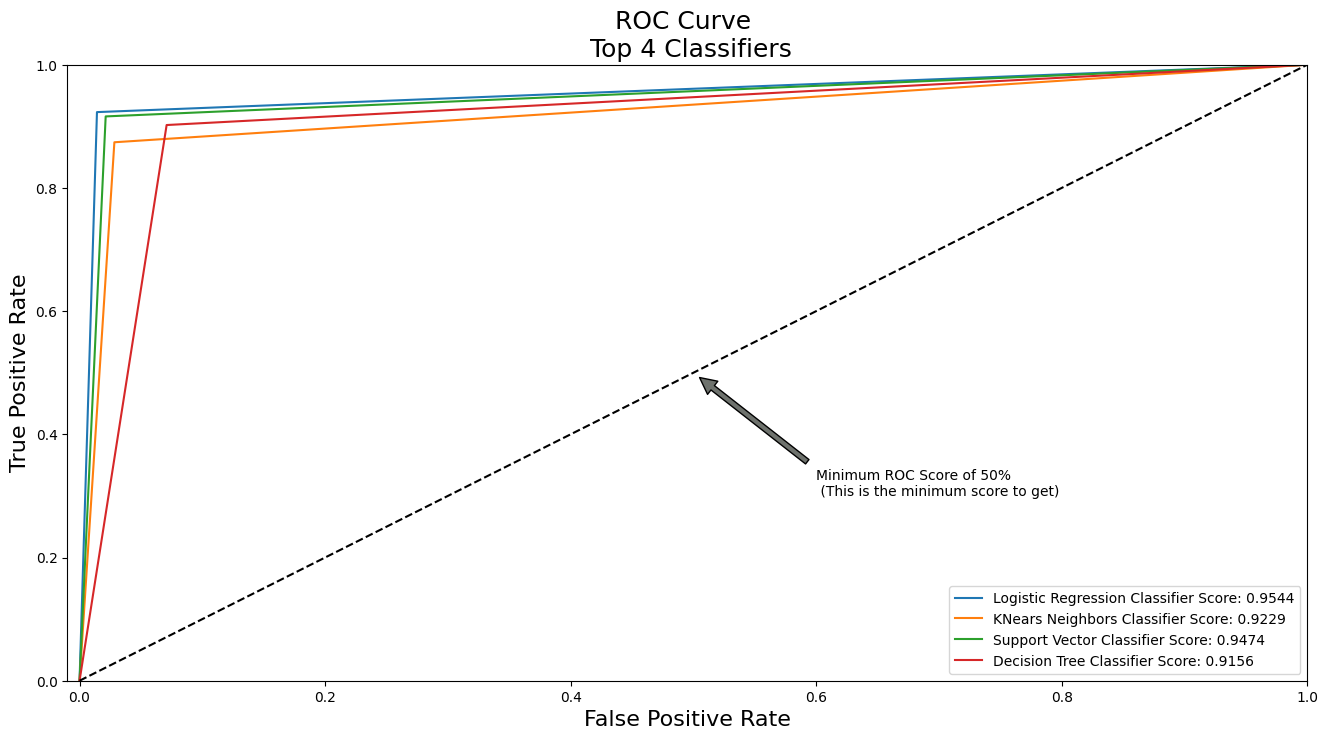

In [68]:
plt.figure(figsize=(16,8))
plt.title('ROC Curve \n Top 4 Classifiers', fontsize=18)
plt.plot(log_fpr, log_tpr, label='Logistic Regression Classifier Score: {:.4f}'.format(roc_auc_score(y_test, log_reg_pred)))
plt.plot(knear_fpr, knear_tpr, label='KNears Neighbors Classifier Score: {:.4f}'.format(roc_auc_score(y_test, knears_pred)))
plt.plot(svc_fpr, svc_tpr, label='Support Vector Classifier Score: {:.4f}'.format(roc_auc_score(y_test, sv_pred)))
plt.plot(tree_fpr, tree_tpr, label='Decision Tree Classifier Score: {:.4f}'.format(roc_auc_score(y_test, tree_pred)))
plt.plot([0, 1], [0, 1], 'k--')
plt.axis([-0.01, 1, 0, 1])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.annotate('Minimum ROC Score of 50% \n (This is the minimum score to get)', xy=(0.5, 0.5), xytext=(0.6, 0.3),
                arrowprops=dict(facecolor='#6E726D', shrink=0.05))
plt.legend()

[Text(0, 0.5, ''), Text(0, 1.5, '')]

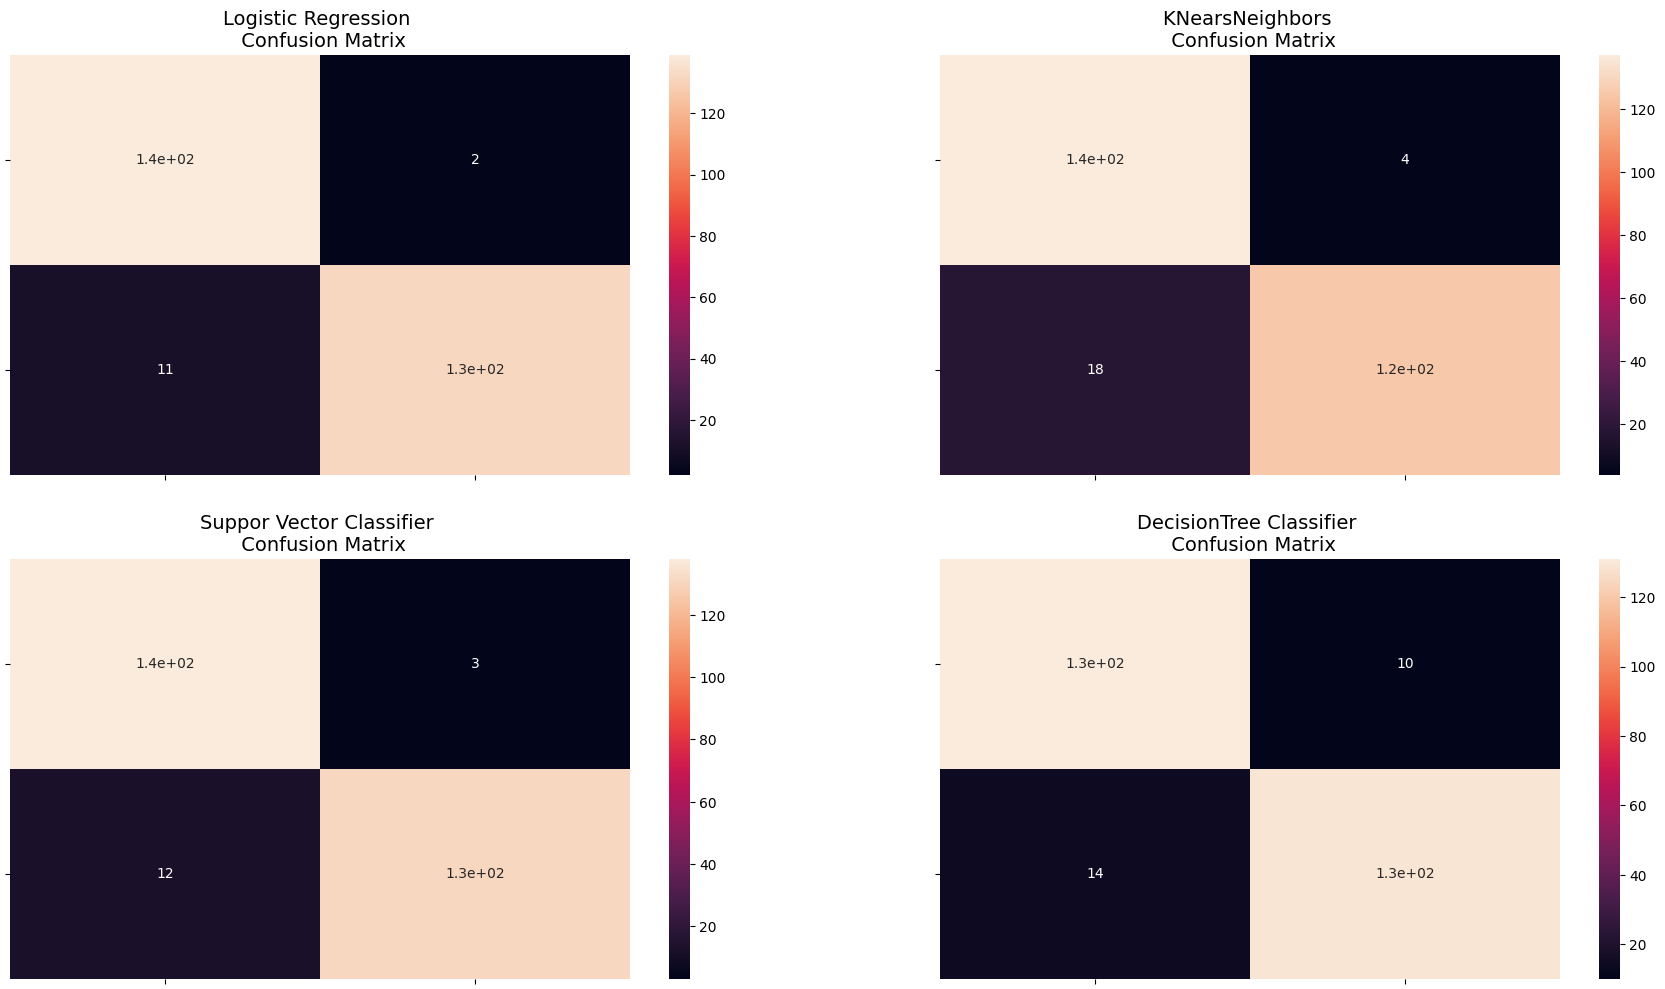

In [70]:
from sklearn.metrics import confusion_matrix
y_pred_log_reg = log_reg.predict(x_test)
y_pred_knear = knears_neighbors.predict(x_test)
y_pred_svc = svc.predict(x_test)
y_pred_tree = tree_clf.predict(x_test)


log_reg_cf = confusion_matrix(y_test, y_pred_log_reg)
kneighbors_cf = confusion_matrix(y_test, y_pred_knear)
svc_cf = confusion_matrix(y_test, y_pred_svc)
tree_cf = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(2, 2,figsize=(22,12))


sns.heatmap(log_reg_cf, ax=ax[0][0], annot=True)
ax[0, 0].set_title("Logistic Regression \n Confusion Matrix", fontsize=14)
ax[0, 0].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[0, 0].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(kneighbors_cf, ax=ax[0][1], annot=True)
ax[0][1].set_title("KNearsNeighbors \n Confusion Matrix", fontsize=14)
ax[0][1].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[0][1].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(svc_cf, ax=ax[1][0], annot=True)
ax[1][0].set_title("Suppor Vector Classifier \n Confusion Matrix", fontsize=14)
ax[1][0].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[1][0].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(tree_cf, ax=ax[1][1], annot=True)
ax[1][1].set_title("DecisionTree Classifier \n Confusion Matrix", fontsize=14)
ax[1][1].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[1][1].set_yticklabels(['', ''], fontsize=14, rotation=360)

In [71]:
from sklearn.metrics import classification_report

print('Logistic Regression:')
print(classification_report(y_test, y_pred_log_reg))

print('KNears Neighbors:')
print(classification_report(y_test, y_pred_knear))

print('Support Vector Classifier:')
print(classification_report(y_test, y_pred_svc))

print('Support Vector Classifier:')
print(classification_report(y_test, y_pred_tree))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       141
           1       0.99      0.92      0.95       143

    accuracy                           0.95       284
   macro avg       0.96      0.95      0.95       284
weighted avg       0.96      0.95      0.95       284

KNears Neighbors:
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       141
           1       0.97      0.87      0.92       143

    accuracy                           0.92       284
   macro avg       0.93      0.92      0.92       284
weighted avg       0.93      0.92      0.92       284

Support Vector Classifier:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       141
           1       0.98      0.92      0.95       143

    accuracy                           0.95       284
   macro avg       0.95      0.95      0.95       284
weighted

In [ ]:
# fially choose model wiht leas tfalse negative